# 02 - Features

## Imports

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure
import os

# Make sure we get outputs from a probabilitistic model each time (for reproducibility) 
np.random.seed(1515)

## Image Pre-processing

### What is Pre-processing? 

**Pre-processing** is the process of changing an image so that it is more suited for analysis/model-building. 

For example, in our FRC 2026 REBUILT ball-detection task, some things that would probbably make detection is to make the balls stand out in the image more so the model picks up on them. 

Pre-processing lets us do that. We will be showing what this pre-processing by demoing the individual techniques.

To operationalize this, let us use an image of yellow balls on the field:

![](./ref_imgs/balls_on_field.png)

#### Grayscale

Grayscaling an image involves taking away the color channels so that our model is only in shades of black and white. Mathematically, you can think of it as reducing our matrix from a higher dimension representation with the 3 color channels to simply having the height and width representation. 

Let's see what this looks like on our image: 

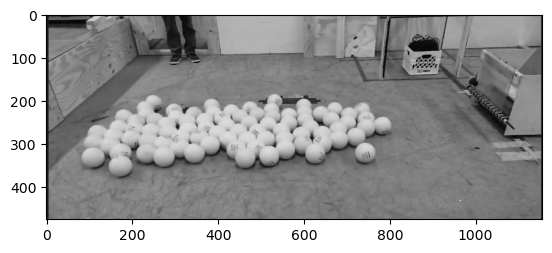

In [42]:
# Read the color image
img_color = cv2.imread('./ref_imgs/balls_on_field.png')

# Convert the image to grayscale
img_grayscale = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Display our new grayscale image 
plt.imshow(img_grayscale, cmap = 'gray')
plt.show()

You might be wondering what the point of grayscaling an image is. Consider that if we had color in our image, and we trained our algorithm, our algorithm might associate being yellow with being a ball. While in our confined space, where we have no other yellow objects, this might work, consider if there was a yellow robot on our field. Our detection might get confused! 

However, if we remove color, our detection has to use other features to decide what a ball is, and will perform better at ball detection. Feel free to dive into all the literature surrounding best pre-processing for object detection (fair warning: it is dense reading!), and you will find empirical evidence for this claim. 

We will dive into what those features could be after pre-processing is done. 

#### Blurring

**Blurring** or **Smoothing** is another common pre-processing technique. Admittedly, this one might seem a bit confusing - why would we want our image quality to be *worse*? 

Looking at our image above, we can see that there are some small spots on the image, or texts on the ball, that would really only serve as a "distraction" to our image. By blurring the image, we smooth over these rapid changes in pixels and make sure our image only consists of the key features like the balls, or the wall. 

Let's see what this looks like: 

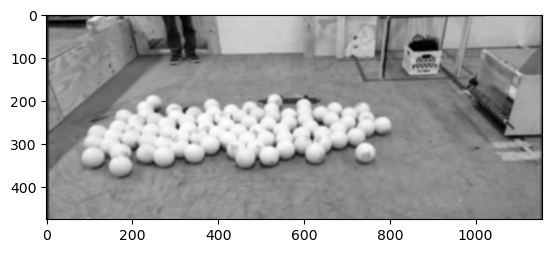

In [56]:
# apply the blur to the image 
img_blurred = cv2.GaussianBlur(img_grayscale, (11, 11), 0) # (11, 11) denotes kernel size, 0 is automatic SD detection 

plt.imshow(img_blurred, cmap = 'gray')
plt.show()

Note that in the code we specify kernel size and another argument of standard deviation (SD) in the X dimension. We will cover some of the basics of kernels in our discussion of convolution with regards to neural networks.

#### De-Noising

Besides general blurring, we can **de-noise** our image to spot-remove any noise in the image. "Noise" is like what we talked about above - anything that might distract from the main parts of the image we want to focus on. 

De-noising, especially when using more complex algorithms, tends to be a lot more effective than simply blurring because it also works towards enhancing relevant features. Again, understanding how these algorithms work is not as important (and well beyond the scope of robotics), but it is key to understand what it is they are doing to better understand how it can give us better data. 

Let's look at what this denoising could be: 

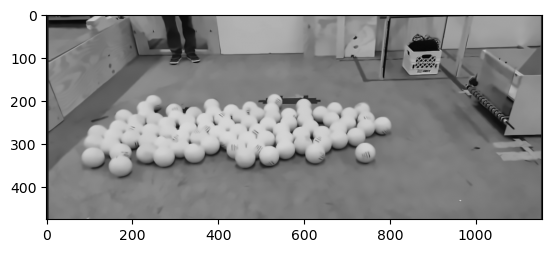

In [64]:
# Parameters are:
    # src: Input image (grayscale)
    # dst: Output image (None, as it's returned by the function)
    # h: Filter strength (higher value removes more noise but also more details; 10 is a good default)
    # templateWindowSize: Size of the template patch (must be odd; recommended 7)
    # searchWindowSize: Size of the search window (must be odd; recommended 21)

denoised_img = cv2.fastNlMeansDenoising(img_grayscale, None, h=10, templateWindowSize=7, searchWindowSize=21)

plt.imshow(denoised_img, cmap = 'gray')
plt.show()

For those who are curious, this algorithm is called Non-local Means Denoising, which essentially denoises by using the average pixel value in a neighborhood of pixels based on their similarity.

#### Brightness Adjustment 

## Features for Images

In the ML primer, we skipped over a discussion of features and how we select them, create them, etc. We will discuss features briefly for the sake of forming a foundation of understanding how features impact our vision-processing capabilities. 

### Traditional ML Features

In a traditional ML context, features are thought of as numeric representations of different variables that we use to predict/categorize our variable of interest. For instance, with our AP Calculus example, our features are fairly easy to think about as numbers: hours studied. 

If we expanded the model, we could go further into quantifying different variables that might influence exam scores. Some of them would be pretty straightforward, like hours of sleep the night before an exam, or your previous exam scores. There are some that would be more complicated to operationalize into models, like the effect of having a good study partner, or how a bad game during basketball ruined your mood and therefore you got a worse score. However, you can still imagine that the effects of the first feature are good, and the second are bad. 

At the end of the day, we can imagine them fairly intuitively.

But what about images - how do we process features for something visual? 

### Image Features

As mentioned in our first notebook, images are matrices/grids of numbers. It stands to reason that the features will be subsets, or smaller parts, of these grids. 

But what are those grids meant to represent? 

#### Edges

An **edge** in an image is usually defined as any area in an image that undergoes a rapid change in intensity. The magnitude and direction of the intensity change is known as a **gradient**. We recall from our previous notebook that intensity is our value that is encoded in the grid, and dictates how "strong" a color is. 

Let's look at what some edges could look like: 

![](./ref_imgs/einstein_edge.png)

As you can see, the edges tend to give us a pretty good idea of the image we are looking at. This is a big reason that edges are considered among the foundational image features, and are still used heavily with more complex classification and object detection techniques. 

To think about why this would be more important than something like color, go back to our conversation about our FRC 2026 REBUILT object detection task of detecting the yellow balls in the field. If our field has any other yellow objects, then our classifier might struggle to determine what is a ball because it is focusing on finding color, whereas a classifier that relies on edges would simply find the edges that match a ball (e.g., the roundness). 